# Modulprojekt DLT – Teil B
## Paraphrasenerkennung mit DistilBERT auf MRPC

Dieses Notebook überträgt die Sentiment-Pipeline aus Teil A auf **Satzpaar-Klassifikation**.


In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

Mounted at /content/drive


## 0 – Einrichtung

Wir installieren die benötigten Pakete. In Colab müssen `transformers`, `datasets`
und `evaluate` in der Regel installiert werden; `peft` nur für die optionale LoRA-Aufgabe.


In [2]:
# In Colab ausführen. Lokal ggf. in einer venv installieren.
%pip install -q "transformers>=4.40" "datasets>=2.19" evaluate scikit-learn peft accelerate
# In Colab ist ein zu altes torchao vorinstalliert, das mit aktuellem peft
# kollidiert (ImportError in Abschnitt 7). LoRA auf BERT braucht torchao nicht,
# daher entfernen wir es. Danach: Laufzeit NICHT neu starten, einfach weiter.
%pip uninstall -y -q torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.3 MB/s eta 0:00:00


In [20]:
import os
import random, numpy as np, torch
import json

SEED = 42
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 128
RESULTS_DIR = "/content/drive/MyDrive/Colab Notebooks/DLT_MP/results"
os.makedirs(RESULTS_DIR, exist_ok=True)


def set_seed_all(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed_all(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)


Device: cuda


## 1 – Datensatz laden und inspizieren

The Microsoft Research Paraphrase Corpus (Dolan & Brockett, 2005) is a corpus of sentence pairs automatically extracted from online news sources, with human annotations for whether the sentences in the pair are semantically equivalent.


In [4]:
from datasets import load_dataset


ds = load_dataset("nyu-mll/glue", "mrpc")
print(ds)
labels = ds["train"].features["label"].names   # ['not_equivalent', 'equivalent']
print("Labels:", labels)
ds["train"][:2]



README.md:   0%|          | 0.00/35.3k [00:00<?, ?B/s]

mrpc/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  649kB            

mrpc/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

mrpc/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 75.7kB            

mrpc/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating train split:   0%|          | 0/3668 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/408 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1725 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1725
    })
})
Labels: ['not_equivalent', 'equivalent']


{'sentence1': ['Amrozi accused his brother , whom he called " the witness " , of deliberately distorting his evidence .',
  "Yucaipa owned Dominick 's before selling the chain to Safeway in 1998 for $ 2.5 billion ."],
 'sentence2': ['Referring to him as only " the witness " , Amrozi accused his brother of deliberately distorting his evidence .',
  "Yucaipa bought Dominick 's in 1995 for $ 693 million and sold it to Safeway for $ 1.8 billion in 1998 ."],
 'label': [1, 0],
 'idx': [0, 1]}

In [5]:
import collections
# Klassenverteilung pro Split
for split in ds:
    c = collections.Counter(ds[split]["label"])
    print(f"{split:11s}: n={len(ds[split]):5d}  not_equivalent={c[0]:5d}  equivalent={c[1]:5d}")

train      : n= 3668  not_equivalent= 1194  equivalent= 2474
validation : n=  408  not_equivalent=  129  equivalent=  279
test       : n= 1725  not_equivalent=  578  equivalent= 1147


unbalanciertes Datenset, equivalent ca. 2/3, not_equivalent ca. 1/3, Verteilung über Splits stabil

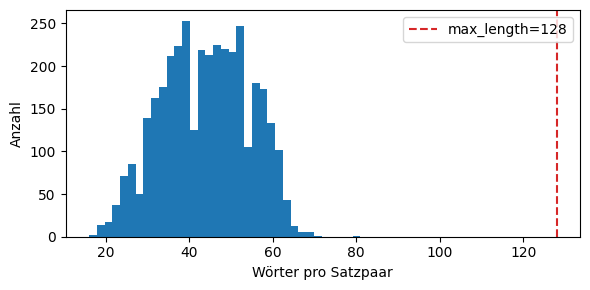

Median: 44  95. Perzentil: 60  Maximum: 81


In [6]:
import matplotlib.pyplot as plt

train_lengths = [len(a.split()) + len(b.split())
                 for a, b in zip(ds["train"]["sentence1"], ds["train"]["sentence2"])]
plt.figure(figsize=(6, 3)); plt.hist(train_lengths, bins=35)
plt.axvline(MAX_LENGTH, color="tab:red", ls="--", label="max_length=128")
plt.xlabel("Wörter pro Satzpaar"); plt.ylabel("Anzahl"); plt.legend()
plt.tight_layout(); plt.show()
print(
    "Median:", int(np.median(train_lengths)),
    " 95. Perzentil:", int(np.percentile(train_lengths,95)),
    " Maximum:", int(np.max(train_lengths))
)

*   50% der Satzpaare bestehen aus 44 oder weniger Wörtern und 50% aus 44 oder mehr.
*   Nur 5% der Satzpaare im Trainingset haben mehr als 60 Wörter.
* Wie kommt man von der Anzahl der Wörter zu der abgeleiteten max_lengths der Tokens? Ein Wort könnte ja auch in mehrere Subwort-Tokens zerlegt werden. Deswegen berechne ich die Verteilung nochmal mit dem Tokenizer ohne Truncation:



In [7]:
from transformers import AutoTokenizer
import numpy as np


tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_pairs(batch, max_length=None, truncation=False):
  tokens = tokenizer(
      batch["sentence1"],
      batch["sentence2"],
      max_length=max_length,
      truncation=truncation
      )

  tokens["length"] = [len(ids) for ids in tokens["input_ids"]]
  return tokens

tokenized = ds.map(tokenize_pairs, batched=True)

lengths = tokenized["train"]["length"]
print("Median:", np.percentile(lengths, 50))
print("95%:", np.percentile(lengths, 95))
print("Maximum:", np.max(lengths))

# Tokenisierungsbeispiel
print(
    tokenizer.convert_ids_to_tokens(
        tokenized["train"][0]["input_ids"]
    )
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/3668 [00:00<?, ? examples/s]

Map:   0%|          | 0/408 [00:00<?, ? examples/s]

Map:   0%|          | 0/1725 [00:00<?, ? examples/s]

Median: 53.0
95%: 74.0
Maximum: 103
['[CLS]', 'am', '##ro', '##zi', 'accused', 'his', 'brother', ',', 'whom', 'he', 'called', '"', 'the', 'witness', '"', ',', 'of', 'deliberately', 'di', '##stor', '##ting', 'his', 'evidence', '.', '[SEP]', 'referring', 'to', 'him', 'as', 'only', '"', 'the', 'witness', '"', ',', 'am', '##ro', '##zi', 'accused', 'his', 'brother', 'of', 'deliberately', 'di', '##stor', '##ting', 'his', 'evidence', '.', '[SEP]']


Die maximale Tokenanzahl beim Trainingset liegt bei bei 103 Tokens inklusive Special Tokens "[CLS]" und "[SEP]".

## 2 – Baselines



1. **Majority-Class**
2. **TF-IDF + logistische Regression**


In [8]:
import collections
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score


X1_tr = ds["train"]["sentence1"]
X2_tr = ds["train"]["sentence2"]
ytr   = ds["train"]["label"]

X1_va = ds["validation"]["sentence1"]
X2_va = ds["validation"]["sentence2"]
yva   = ds["validation"]["label"]

# 1) Majority class
maj = collections.Counter(ytr).most_common(1)[0][0]
pred_maj = [maj] * len(yva)
print(
    f"Majority : "
    f"acc={accuracy_score(yva, pred_maj):.3f}  "
    f"macro-F1={f1_score(yva, pred_maj, average='macro'):.3f}"
)
# 2) TF-IDF + LogReg
vec = TfidfVectorizer(ngram_range=(1, 2),min_df=2)
# learn vocabulary from training sentences1 + sentences2
vec.fit(list(X1_tr) + list(X2_tr))
# transform every sentence separately in same vec space
v1_tr = vec.transform(X1_tr)
v2_tr = vec.transform(X2_tr)

v1_va = vec.transform(X1_va)
v2_va = vec.transform(X2_va)

# difference between the sentences
diff_tr = abs(v1_tr - v2_tr)
diff_va = abs(v1_va - v2_va)
# simitarities
prod_tr = v1_tr.multiply(v2_tr)
prod_va = v1_va.multiply(v2_va)
# concatenate both feature types
Xtr_pair = hstack([diff_tr, prod_tr])
Xva_pair = hstack([diff_va, prod_va])
# Log Reg classifier
clf = LogisticRegression(max_iter=1000)
clf.fit(Xtr_pair, ytr)
pred_lr = clf.predict(Xva_pair)
print(
    f"TF-IDF+LR: "
    f"acc={accuracy_score(yva, pred_lr):.3f}  "
    f"macro-F1={f1_score(yva, pred_lr, average='macro'):.3f}"
)

Majority : acc=0.684  macro-F1=0.406
TF-IDF+LR: acc=0.735  macro-F1=0.568


## 3 – Tokenisierung

Diesmal mit Truncation und max_length. Dynamisches Padding folgt später.


In [9]:
ds_tok = ds.map(
    tokenize_pairs,
    batched=True,
    fn_kwargs={"max_length": MAX_LENGTH, "truncation": True}
    )

print(tokenizer.convert_ids_to_tokens(ds_tok["train"][0]["input_ids"]))
ds_tok["train"][0].keys()

Map:   0%|          | 0/3668 [00:00<?, ? examples/s]

Map:   0%|          | 0/408 [00:00<?, ? examples/s]

Map:   0%|          | 0/1725 [00:00<?, ? examples/s]

['[CLS]', 'am', '##ro', '##zi', 'accused', 'his', 'brother', ',', 'whom', 'he', 'called', '"', 'the', 'witness', '"', ',', 'of', 'deliberately', 'di', '##stor', '##ting', 'his', 'evidence', '.', '[SEP]', 'referring', 'to', 'him', 'as', 'only', '"', 'the', 'witness', '"', ',', 'am', '##ro', '##zi', 'accused', 'his', 'brother', 'of', 'deliberately', 'di', '##stor', '##ting', 'his', 'evidence', '.', '[SEP]']


dict_keys(['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask', 'length'])

## 4 – Feintuning mit dem `Trainer`



In [10]:
from transformers import (AutoModelForSequenceClassification, TrainingArguments,
                          Trainer, DataCollatorWithPadding)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2,
    id2label={0:"not_equivalent",1:"equivalent"},
    label2id={"not_equivalent":0,"equivalent":1}
    )

collator = DataCollatorWithPadding(tokenizer)  # dynamisches Padding pro Batch

def compute_metrics(eval_pred):
    logits, y = eval_pred
    pred = logits.argmax(-1)
    return {"accuracy": accuracy_score(y, pred),
            "macro_f1": f1_score(y, pred, average="macro")}

args = TrainingArguments(
    output_dir="out",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    seed=SEED,
    report_to="none",
)

trainer = Trainer(
    model=model, args=args,
    train_dataset=ds_tok["train"],
    eval_dataset=ds_tok["validation"],
    data_collator=collator,
    compute_metrics=compute_metrics,
)
trainer.train()

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.545912,0.407793,0.835784,0.806379
2,0.359962,0.354677,0.850490,0.820401
3,0.247278,0.389397,0.848039,0.813297


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=690, training_loss=0.38438424925873244, metrics={'train_runtime': 114.1637, 'train_samples_per_second': 96.388, 'train_steps_per_second': 6.044, 'total_flos': 215773868887344.0, 'train_loss': 0.38438424925873244, 'epoch': 3.0})

## 5 – Evaluation auf dem Test-Set




BERT test: acc=0.821  macro-F1=0.798

                precision    recall  f1-score   support

not_equivalent       0.74      0.71      0.73       578
    equivalent       0.86      0.88      0.87      1147

      accuracy                           0.82      1725
     macro avg       0.80      0.79      0.80      1725
  weighted avg       0.82      0.82      0.82      1725



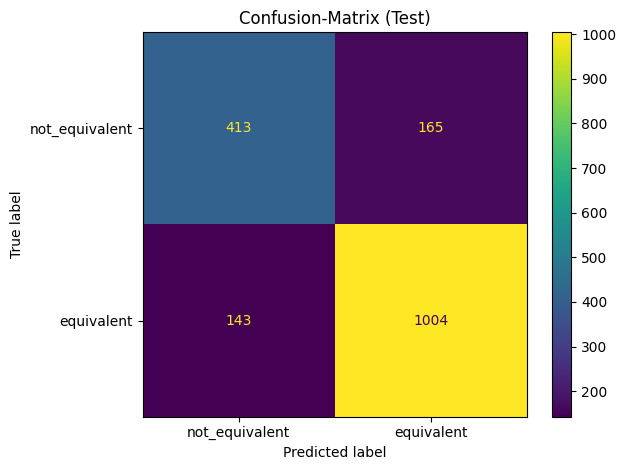

In [11]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

pred_out = trainer.predict(ds_tok["test"])
y_true = pred_out.label_ids
y_pred = pred_out.predictions.argmax(-1)

print(f"BERT test: acc={accuracy_score(y_true,y_pred):.3f}  "
      f"macro-F1={f1_score(y_true,y_pred,average='macro'):.3f}\n")
print(classification_report(y_true, y_pred, target_names=labels))

ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=labels)
plt.title("Confusion-Matrix (Test)"); plt.tight_layout(); plt.show()

## 6 – Qualitative Fehleranalyse



In [12]:
test_sent1 = ds["test"]["sentence1"]
test_sent2 = ds["test"]["sentence2"]
errors = [(test_sent1[i], test_sent2[i], labels[y_true[i]], labels[y_pred[i]])
          for i in range(len(y_true)) if y_true[i] != y_pred[i]]
print(f"{len(errors)} Fehler von {len(y_true)} Beispielen\n")
for sent1, sent2, gold, pred in errors[:10]:
    print(f"[gold={gold:14s} | pred={pred:14}]"
          f"\n{'':5s}1. {sent1}"
          f"\n{'':5s}2. {sent2}")

308 Fehler von 1725 Beispielen

[gold=equivalent     | pred=not_equivalent]
     1. The world 's two largest automakers said their U.S. sales declined more than predicted last month as a late summer sales frenzy caused more of an industry backlash than expected .
     2. Domestic sales at both GM and No. 2 Ford Motor Co. declined more than predicted as a late summer sales frenzy prompted a larger-than-expected industry backlash .
[gold=not_equivalent | pred=equivalent    ]
     1. A tropical storm rapidly developed in the Gulf of Mexico Sunday and was expected to hit somewhere along the Texas or Louisiana coasts by Monday night .
     2. A tropical storm rapidly developed in the Gulf of Mexico on Sunday and could have hurricane-force winds when it hits land somewhere along the Louisiana coast Monday night .
[gold=not_equivalent | pred=equivalent    ]
     1. Hong Kong was flat , Australia , Singapore and South Korea lost 0.2-0.4 percent .
     2. Australia was flat , Singapore was down

## 7 – LoRA / Parameter-effizientes Feintuning



In [13]:
from peft import LoraConfig, get_peft_model, TaskType

base = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
lora_cfg = LoraConfig(
    task_type=TaskType.SEQ_CLS, r=8, lora_alpha=16, lora_dropout=0.1,
    target_modules=["q_lin","v_lin"],   # DistilBERT-Attention; bei BERT: ["query","value"]
)
lora_model = get_peft_model(base, lora_cfg)
lora_model.print_trainable_parameters()   # vergleiche mit ~67M des vollen Modells

# Danach: denselben Trainer-Block wie in Abschnitt 4, aber model=lora_model.

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 739,586 || all params: 67,694,596 || trainable%: 1.0925


In [14]:
args_lora = TrainingArguments(
    output_dir="out_lora",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    seed=SEED,
    report_to="none",
)

trainer_lora = Trainer(
    model=lora_model, args=args_lora,
    train_dataset=ds_tok["train"],
    eval_dataset=ds_tok["validation"],
    data_collator=collator,
    compute_metrics=compute_metrics,
)
trainer_lora.train()

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.627607,0.608953,0.683824,0.406114
2,0.610801,0.602032,0.683824,0.406114
3,0.606229,0.599597,0.683824,0.406114


TrainOutput(global_step=690, training_loss=0.6148790884709012, metrics={'train_runtime': 65.1726, 'train_samples_per_second': 168.844, 'train_steps_per_second': 10.587, 'total_flos': 219474703981152.0, 'train_loss': 0.6148790884709012, 'epoch': 3.0})

## 8 – Lernkurve

- **Daten-Effizienz / Lernkurve:** Accuracy vs. Trainingsgröße


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'train_runtime': '5.869', 'train_samples_per_second': '127.8', 'train_steps_per_second': '8.179', 'train_loss': '0.6398', 'epoch': '3'}
n=  250  seed= 42 
acc=0.699  macro-F1=0.454 



Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'train_runtime': '86.59', 'train_samples_per_second': '127.1', 'train_steps_per_second': '7.969', 'train_loss': '0.3749', 'epoch': '3'}
n= 3668  seed=123 
acc=0.855  macro-F1=0.817 



Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'train_runtime': '86.54', 'train_samples_per_second': '127.2', 'train_steps_per_second': '7.973', 'train_loss': '0.3796', 'epoch': '3'}
n= 3668  seed=456 
acc=0.863  macro-F1=0.826 

n=  250  acc=0.693 ± 0.008  macro-F1=0.436 ± 0.026
n= 1000  acc=0.757 ± 0.043  macro-F1=0.665 ± 0.095
n= 3668  acc=0.859 ± 0.004  macro-F1=0.823 ± 0.005


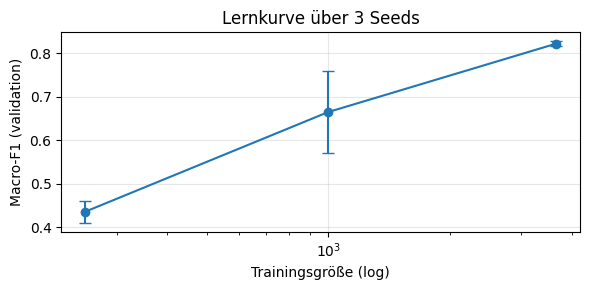

In [26]:
# Vollständiges Beispiel: Lernkurve (Macro-F1 vs. Trainingsgröße).
# Wir kapseln Training + Evaluation in eine Funktion und rufen sie in einer Schleife.
# Für Robustheit sollte man je Größe mehrere Seeds mitteln; hier ein Seed pro Größe,
# damit es auf CPU schnell bleibt.

def train_eval(n_train, seed, epochs=3):
    """Trainiert DistilBERT auf n_train Beispielen und gibt (acc, macro_f1) auf
    dem validation-Split zurück. Nutzt dieselbe Tokenisierung wie oben."""
    set_seed_all(seed)
    sub = (ds_tok["train"].shuffle(seed=seed).select(range(n_train)))

    m = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2,
        id2label={0:"not_equivalent",1:"equivalent"},
        label2id={"not_equivalent":0,"equivalent":1}
        )

    a = TrainingArguments(
        output_dir=f"out_lc_{n_train}_seed{seed}",
        num_train_epochs=epochs,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=2e-5,
        eval_strategy="no",       # wir evaluieren einmal am Ende selbst
        save_strategy="no",
        seed=seed,
        report_to="none",
        logging_strategy="no",
        disable_tqdm=True,
    )
    tr = Trainer(model=m, args=a, train_dataset=sub,
                 data_collator=collator, compute_metrics=compute_metrics)
    tr.train()

    out = tr.predict(ds_tok["validation"])
    yp = out.predictions.argmax(-1)
    yt = out.label_ids
    return accuracy_score(yt, yp), f1_score(yt, yp, average="macro")

max_n = len(ds["train"])
sizes = [250, 1000, max_n]
lc = {}
seeds = [42, 123, 456]

for n in sizes:
    lc[n] = []
    for seed in seeds:
        acc, mf1 = train_eval(n, seed=seed)
        lc[n].append({"seed": seed, "accuracy": acc, "macro_f1": mf1})
        print(
            f"n={n:5d}  seed={seed:3d} \n"
            f"acc={acc:.3f}  macro-F1={mf1:.3f} \n"
        )

lc_summary = {}
for n in sizes:
    accs = [run["accuracy"] for run in lc[n]]
    f1s = [run["macro_f1"] for run in lc[n]]
    lc_summary[n] = {
        "accuracy_mean": np.mean(accs),
        "accuracy_std": np.std(accs, ddof=1),
        "macro_f1_mean": np.mean(f1s),
        "macro_f1_std": np.std(f1s, ddof=1)
    }

    print(
        f"n={n:5d}  "
        f"acc={np.mean(accs):.3f} ± {np.std(accs, ddof=1):.3f}  "
        f"macro-F1={np.mean(f1s):.3f} ± {np.std(f1s, ddof=1):.3f}"
    )

plt.figure(figsize=(6, 3))
plt.errorbar(
    sizes,
    [lc_summary[n]["macro_f1_mean"] for n in sizes],
    yerr=[lc_summary[n]["macro_f1_std"] for n in sizes],
    marker="o",
    capsize=4
)

plt.xscale("log")
plt.xlabel("Trainingsgröße (log)")
plt.ylabel("Macro-F1 (validation)")
plt.title("Lernkurve über 3 Seeds")
plt.grid(True, alpha=.3)
plt.tight_layout()
plt.show()

# Ergebnisse für den Bericht sichern
lc_path = os.path.join(RESULTS_DIR, "learning_curve.json")
with open(lc_path, "w") as f:
    json.dump(lc, f, indent=2)


## 9 – Speichern der Ergebnisse




In [24]:
metrics = {
    "model": MODEL_NAME, "seed": SEED, "max_length": MAX_LENGTH,
    "test_accuracy": float(accuracy_score(y_true, y_pred)),
    "test_macro_f1": float(f1_score(y_true, y_pred, average="macro")),
    "baseline_majority_f1": float(f1_score(yva, pred_maj, average="macro")),
    "baseline_tfidf_f1": float(f1_score(yva, pred_lr, average="macro")),
}

metrics_path = os.path.join(RESULTS_DIR, "metrics.json")
with open(metrics_path,"w") as f:
    json.dump(metrics, f, indent=2)
print(json.dumps(metrics, indent=2))
# trainer.save_model("results/model")   # optional, groß

{
  "model": "distilbert-base-uncased",
  "seed": 42,
  "max_length": 128,
  "test_accuracy": 0.8214492753623188,
  "test_macro_f1": 0.7977035757692061,
  "baseline_majority_f1": 0.40611353711790393,
  "baseline_tfidf_f1": 0.5677796523717974
}
